# Demo for the ProblemsSolvers class.

This script is intended to help with debugging problems and solvers.

It create problem-solver groups (using the directory) and runs multiple macroreplications of each problem-solver pair.

## Append SimOpt Path

Since the notebook is stored in simopt/notebooks, we need to append the parent simopt directory to the system path to import the necessary modules later on.

In [156]:
import sys
from pathlib import Path

import random 
import numpy as np 

# Take the current directory, find the parent, and add it to the system path
sys.path.append(str(Path.cwd().parent))

## Configuration Parameters

This section defines the core parameters for the demo.

To query model/problem/solver names, run `python scripts/list_directories.py`

In [157]:
# Specify the names of the solver(s) and problem(s) to test.
solver_abbr_names = ["ASTROMORF"] #add NELDMD once fixed

problem_abbr_names =  ["FACSIZE-1", "DYNAMNEWS-1", "CONTAM-2", "ROSENBROCK-1"]
num_macroreps = 5
num_postreps = 10  
num_postreps_init_opt = 10

In [158]:
from simopt.experiment_base import ProblemSolver, ProblemsSolvers
def populate_experiments(problems, solvers):
    # Create a list of list of ProblemSolvers to be passed through the ProblemsSolvers constructor 
    problem_solvers = []
    for solver in solvers : 
        solvers_ps = []
        if solver.name == 'ASTROMORF' :
            solver_rename = f'ASTROMORF_dim{solver.factors["initial subspace dimension"]}'
        else : 
            solver_rename = solver.name
        for problem in problems :
            solvers_ps.append(ProblemSolver(problem=problem, solver=solver, solver_rename=solver_rename))
        problem_solvers.append(solvers_ps)

    return problem_solvers

In [159]:
def update_model_factors_dimensions(problem_name: str, new_dim: int) -> dict:
	"""
		Find the model associated with model_name and update the dimension of the factor values to the new_dim.
		Return the updated model factors.

	Args:
		model_name (str): Name of Model
		new_dim (int): New dimension for the model

	Returns:
		dict: Updated model factors
	"""
	new_factors = {}
	if problem_name == 'DYNAMNEWS-1':
		new_factors= {
			'num_prod': new_dim,
			'c_utility': [6 + j for j in range(new_dim)],
			'init_level': [3] * new_dim,
			'price': [9] * new_dim,
			'cost': [5] * new_dim,
		}
	elif problem_name == 'FACSIZE-1' or problem_name == 'FACSIZE-2':
		A = np.random.rand(new_dim, new_dim)
		new_factors= {
			'mean_vec': [500] * new_dim,
			'cov': (np.dot(A, A.T) * 100).tolist(),
			'capacity': [random.randint(100,900) for _ in range(new_dim)],
			'n_fac': new_dim,
		}
	elif problem_name == 'FIXEDSAN-1' :
		new_factors= {
		}
	elif problem_name == 'AIRLINE-1' or problem_name == 'AIRLINE-2' :
		num_classes = random.randint(2,new_dim//2)
		odf_leg_matrix = np.random.randint(0,2,(new_dim, num_classes))
		new_factors= {
			'num_classes': num_classes,
			'ODF_leg_matrix': odf_leg_matrix.tolist(),
			'prices': tuple([random.randint(50,300) for _ in range(new_dim)]),
			'capacity': tuple([random.randint(20,150) for _ in range(num_classes)]),
			'booking limits': tuple([random.randint(5,20) for _ in range(new_dim)]),
			'alpha': tuple([random.uniform(0,5) for _ in range(new_dim)]),
			'beta':  tuple([random.uniform(2,10) for _ in range(new_dim)]),
			'gamma_shape': tuple([random.uniform(2,10) for _ in range(new_dim)]),
			'gamma_scale': tuple([random.uniform(10,50) for _ in range(new_dim)]),
		}
	elif problem_name == 'NETWORK-1' :
		process_prob_elem = 1/new_dim
		mode_transit_time = [round(np.random.uniform(0.01,5),3) for _ in range(new_dim)]
		lower_limits_transit_time = [x/2 for x in mode_transit_time] 
		upper_limits_transit_time = [2*x for x in mode_transit_time]
		new_factors= {
			'process_prob': [process_prob_elem] * new_dim,
			'cost_process': [0.1 / (x + 1) for x in range(new_dim)],
			'cost_time': [round(np.random.uniform(0.01,1),3) for _ in range(new_dim)],
			'mode_transit_time': mode_transit_time,
			'lower_limits_transit_time': lower_limits_transit_time,
			'upper_limits_transit_time': upper_limits_transit_time,
			'n_networks': new_dim,
		}
	elif problem_name == 'CONTAM-2' :
		new_factors= {
			'stages': new_dim,
			'prev_decision': (0,) * new_dim,
		}
	
	return new_factors


def update_problem_factor_dimensions(problem_name: str, new_dim: int, budget: int) -> dict:
	"""
		Update the dimension of the factor values in problem_factors to the new_dim.
		Return the updated problem factors.

	Args:
		problem_factors (dict): Problem factors to be updated
		new_dim (int): New dimension for the problem factors

	Returns:
		dict: Updated problem factors
	"""
	new_factors = {}
	if problem_name == 'DYNAMNEWS-1':
		new_factors =  {
			'initial_solution': (3,) * new_dim,
			'budget': budget,
		}
	elif problem_name == 'FACSIZE-1':
		new_factors =  {
			'initial_solution': (100,) * new_dim,
			'installation_costs': (1,) * new_dim,
			'epsilon': 0.05,
			'budget': budget,
		}
	elif problem_name == 'FACSIZE-2':
		new_factors =  {
			'initial_solution': (300,) * new_dim,
			'installation_costs': (1,) * new_dim,
			'installation_budget': 500.0,
			'budget': budget,
		}
	elif problem_name == 'FIXEDSAN-1' : 
		new_factors =  {
			'budget': budget,
		}
	elif problem_name == 'AIRLINE-1' or problem_name == 'AIRLINE-2' :
		new_factors =  {
			'initial_solution': (3,) * new_dim,
			'budget': budget,
		}
	elif problem_name == 'NETWORK-1' :
		init_soln_elem = 1/new_dim
		new_factors =  {
			'initial_solution': (init_soln_elem,) * new_dim,
			'budget': budget,
		}
	elif problem_name == 'CONTAM-2' :
		new_factors = {
			'initial_solution': (1,) * new_dim,
			'prev_cost': [1] * new_dim,
			'error_prob': [0.2] * new_dim,
			'upper_thres': [0.1] * new_dim,
			'budget': budget,
		}
	return new_factors

In [160]:

from simopt.experiment_base import instantiate_problem, instantiate_solver
from simopt.solvers.astromorf import PolyBasisType
#Create Solver and Problem instances
budget = 2000 
degree = 2

experiments = []
#create a list of ASTROMoRF at a specific dimension and add all the problems to it
for dim in list(range(1,10)):
    solver_factors = {'initial subspace dimension' : dim, 'polynomial degree': degree}
    ps = ProblemSolver(solver_name="ASTROMORF", solver_rename=f'ASTROMORF_dim{dim}', problem_name="FACSIZE-1", solver_fixed_factors=solver_factors)
    experiments.append([ps])

#print out the solver names and problem names being run
# for exp in experiments :
#     for ps in exp :
#         print (f'Running solver {ps.solver.name} on problem {ps.problem.name}')

myexperiment = ProblemsSolvers(experiments=experiments, file_name_path='ASTROMoRF_dimensions_test.pickle')
# # Run a fixed number of macroreplications of the solver on the problem.
myexperiment.run(n_macroreps=num_macroreps)


Finished running ASTROMORF_dim1 on FACSIZE-1 in 23.723 seconds over 5 mreps.
Writing function estimate and budget history data to CSV files...
Finished running ASTROMORF_dim2 on FACSIZE-1 in 8.201 seconds over 5 mreps.
Writing function estimate and budget history data to CSV files...
Finished running ASTROMORF_dim3 on FACSIZE-1 in 22.902 seconds over 5 mreps.
Writing function estimate and budget history data to CSV files...
Finished running ASTROMORF_dim4 on FACSIZE-1 in 16.07 seconds over 5 mreps.
Writing function estimate and budget history data to CSV files...
Finished running ASTROMORF_dim5 on FACSIZE-1 in 39.929 seconds over 5 mreps.
Writing function estimate and budget history data to CSV files...
Finished running ASTROMORF_dim6 on FACSIZE-1 in 56.309 seconds over 5 mreps.
Writing function estimate and budget history data to CSV files...
Finished running ASTROMORF_dim7 on FACSIZE-1 in 74.107 seconds over 5 mreps.
Writing function estimate and budget history data to CSV files...
F

In [161]:
def run_difference_variance(runs):
    # Convert each run into a 2D NumPy array
    runs = [np.array(run) for run in runs]  # shape: (iters, dims)

    # 1. Compute centroid (mean recommended solution) for each run
    centroids = np.array([run.mean(axis=0) for run in runs])
    # shape: (num_runs, dims)

    # 2. Compute variance across runs
    # When there's only 1 run, variance is 0 (not NaN)
    if len(centroids) == 1:
        variance_across_runs = np.zeros(centroids.shape[1])
        avg_variance = 0.0
    else:
        variance_across_runs = np.var(centroids, axis=0, ddof=1)
        # 3. Optional: combine into a single scalar
        avg_variance = variance_across_runs.mean()

    return avg_variance, variance_across_runs, centroids

In [162]:
from simopt.base import Solution
from mrg32k3a.mrg32k3a import MRG32k3a

data_list = [a for x in myexperiment.experiments for a in x]
vars_for_subs = {}

#Summarize results
for exp in data_list : 
    print(f'The number of iterations for solver {exp.solver.name} on problem {exp.problem.name} is: {len(exp.all_recommended_xs[0])}')
    terminal_sols =  [exp.all_recommended_xs[i][-1] for i in range(len(exp.all_recommended_xs))]
    
    # Create new solutions and attach RNGs for simulation
    terminal_sol = []
    for i in range(len(terminal_sols)):
        sol = Solution(tuple(terminal_sols[i]), exp.problem)
        # Create and attach RNGs to the solution
        rng_list = [MRG32k3a(s_ss_sss_index=[i + 1000, ss, 0]) for ss in range(exp.problem.model.n_rngs)]
        sol.attach_rngs(rng_list, copy=True)
        terminal_sol.append(sol)

    [exp.problem.simulate(terminal_sol[i], 750) for i in range(len(terminal_sol))]

    #terminal_sol_and_vals is a list of tuples of the objective function value and corresponding solution
    terminal_sol_and_vals = [(terminal_sol[i].objectives_mean.item(), terminal_sol[i]) for i in range(len(terminal_sol))]

    if exp.problem.minmax[0] == 1 :
        #within terminal_sol_and_vals find the maximum objective value and corresponding solution
        optimal_sol_val =  max(terminal_sol_and_vals, key=lambda x: x[0])
    else : 
        optimal_sol_val =  min(terminal_sol_and_vals, key=lambda x: x[0])


    #Group together all solutions of the same iteration at each macroreplication
    avg_rns, var_across_runs, centroids = run_difference_variance(exp.all_recommended_xs)
    print(f"Average variance (difference across runs):\n {avg_rns}")
    print(f"Variance per dimension:\n {var_across_runs}")
    print(f"Centroids (mean solution per run):\n {centroids}")
    if "ASTROMORF" in exp.solver.name :
        vars_for_subs[exp.solver.factors['initial subspace dimension']] = float(avg_rns)
    

    print(f'Variance of recommended solutions at each iteration for solver {exp.solver.name} on problem {exp.problem.name} is: {float(avg_rns)}')

    print(f'The best solution found by solver {exp.solver.name} on problem {exp.problem.name} is: \n{optimal_sol_val[1].x} \n {optimal_sol_val[0]}')
    print(f'The average objective value over all macroreplications is: {np.mean([terminal_sol_and_vals[i][0] for i in range(len(terminal_sol_and_vals))])}')
    print(' ')



The number of iterations for solver ASTROMORF_dim1 on problem FACSIZE-1 is: 8
Average variance (difference across runs):
 0.38842343217358377
Variance per dimension:
 [0.38842199 0.38842359 0.38842359 0.38842359 0.38842359 0.38842359
 0.38842359 0.38842359 0.38842359 0.38842359]
Centroids (mean solution per run):
 [[199.15331651 199.1533165  199.1533165  199.1533165  199.1533165
  199.1533165  199.1533165  199.1533165  199.1533165  199.1533165 ]
 [199.3592349  199.35923659 199.35923659 199.35923659 199.35923659
  199.35923659 199.35923659 199.35923659 199.35923659 199.35923659]
 [199.0677615  199.06775566 199.06775566 199.06775566 199.06775566
  199.06775566 199.06775566 199.06775566 199.06775566 199.06775566]
 [198.79024362 198.79024093 198.79024093 198.79024093 198.79024093
  198.79024093 198.79024093 198.79024093 198.79024093 198.79024093]
 [200.40929729 200.40929729 200.40929729 200.40929729 200.40929729
  200.40929729 200.40929729 200.40929729 200.40929729 200.40929729]]
Variance 

In [163]:
print("Post-processing results.")
# Run a fixed number of postreplications at all recommended solutions.
myexperiment.post_replicate(n_postreps=num_postreps)

Post-processing results.


In [164]:
print("Post-normalizing results.")

# Find an optimal solution x* for normalization.
myexperiment.post_normalize(n_postreps_init_opt=num_postreps_init_opt)

Post-normalizing results.


Plotting results...
Plot saved to [PosixPath('/Users/benjaminrees/Desktop/simopt/experiments/2025-12-01_00-02-16/plots/SOLVER_SET_PROBLEM_SET_profile_cdf_0.1_solve_times (1) (2) (3) (4) (5) (6) (7) (8) (9) (10) (11) (12).png')]
Plotting complete!


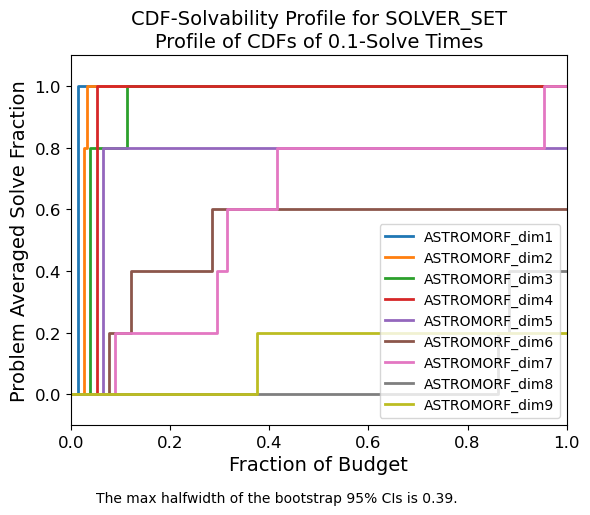

In [165]:
# Produce basic plots.
%matplotlib inline
from simopt.experiment_base import PlotType, plot_solvability_profiles

print("Plotting results...")

def _print_path(plot_path: list[Path]) -> Path:
    print(f"Plot saved to {plot_path!s}")
    return plot_path[0]



group_plot = _print_path(
    plot_solvability_profiles(
        experiments=myexperiment.experiments, plot_type=PlotType.CDF_SOLVABILITY, solve_tol=0.1, plot_conf_ints=False, legend_loc="lower right"
    )
)


print("Plotting complete!")

Plot saved to [PosixPath('/Users/benjaminrees/Desktop/simopt/experiments/2025-12-01_00-02-16/plots/SOLVER_SET_FACSIZE-1_mean_prog_curve_unnorm (1) (2).png')]


PosixPath('/Users/benjaminrees/Desktop/simopt/experiments/2025-12-01_00-02-16/plots/SOLVER_SET_FACSIZE-1_mean_prog_curve_unnorm (1) (2).png')

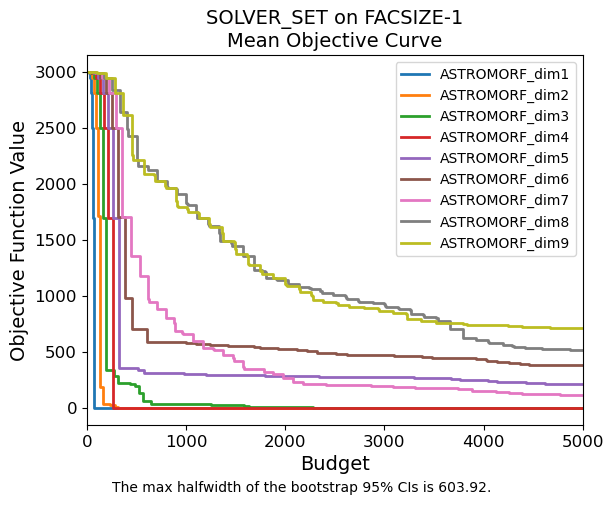

In [166]:
#plot individual plots 
from simopt.experiment_base import plot_progress_curves

ind_plots = []
no_probs = len(problem_abbr_names)

_print_path(
    plot_progress_curves(
        experiments=data_list, plot_type=PlotType.MEAN, normalize=False, all_in_one=True, legend_loc="upper right", plot_conf_ints=False
    )
)

# for idx in range(len(data_list)//2):
#     # _print_path(
#     # plot_progress_curves(
#     #     experiments=[myexperiment], plot_type=PlotType.ALL, normalize=False
#     #     )
#     # )
#     #For astrodf
#     ind_plot_astrodf = _print_path(
#         plot_progress_curves(
#             experiments=[data_list[idx]], plot_type=PlotType.MEAN, normalize=False
#         )
#     )
#     ind_plots.append(ind_plot_astrodf)

#     ind_plot_astromorf = _print_path(
#         plot_progress_curves(
#             experiments=[data_list[no_probs + idx]], plot_type=PlotType.MEAN, normalize=False
#         )
#     )
#     ind_plots.append(ind_plot_astromorf)

In [167]:
# #show plots
# from IPython.display import Image, display
# from pathlib import Path

# plots = ind_plots 

# no_of_prolems = len(problem_abbr_names)


# for i in range(len(plots)) :
#     display(Image(filename=str(plots[i])))
# # Example POSIX path
# # for i in range(no_of_prolems) :
# #     # Display the image
# #     other_solver_same_problem_index = i + no_of_prolems if i < no_of_prolems else i - no_of_prolems
# #     display(Image(filename=str(ind_plots[i])))
# #     #display the same p
# #     display(Image(filename=str(ind_plots[other_solver_same_problem_index])))

# #Display solvability profile
# display(Image(filename=str(group_plot)))

